# Introduction to Key Libraries for Regression Problems

In this notebook, we will explore the fundamental libraries used for regression problems in Python. 
We will generate a dummy dataset, visualize the correlation between features, train a simple Linear Regression model, and evaluate its performance using standard metrics.

We will also introduce two important evaluation metrics:
- **Mean Squared Error (MSE)**: Measures the average squared difference between actual and predicted values. A lower MSE indicates a better fit.
- **R-squared (R²) Score**: Represents how well the independent variables explain the variance in the target variable. A value closer to 1 indicates a better fit.

  The formula for R² is:
  
$$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$
  
Where:
$$
y_i \text{ are the actual values}
$$
$$
\hat{y}_i \text{ are the predicted values}
$$
$$
\bar{y} \text{ is the mean of the actual values}
$$

In [ ]:
import numpy as np  # Numerical computing
import pandas as pd  # Data manipulation
import matplotlib.pyplot as plt  # Data visualization
import seaborn as sns  # Advanced data visualization
from sklearn.model_selection import train_test_split  # Splitting dataset
from sklearn.preprocessing import StandardScaler  # Data scaling
from sklearn.linear_model import LinearRegression  # Linear Regression model
from sklearn.metrics import mean_squared_error, r2_score  # Evaluation metrics
# from sklearn.logistic import LogisticRegression  # Logistic Regression model

ModuleNotFoundError: No module named 'sklearn.logistic'

,Feature1,Feature2,Feature3,Target
0,3.745401,0.314292,6.420316,11.327347
1,9.507143,6.364104,0.841400,27.218228
2,7.319939,3.143560,1.616287,26.247706
3,5.986585,5.085707,8.985542,19.227593
4,1.560186,9.075665,6.064291,0.630274


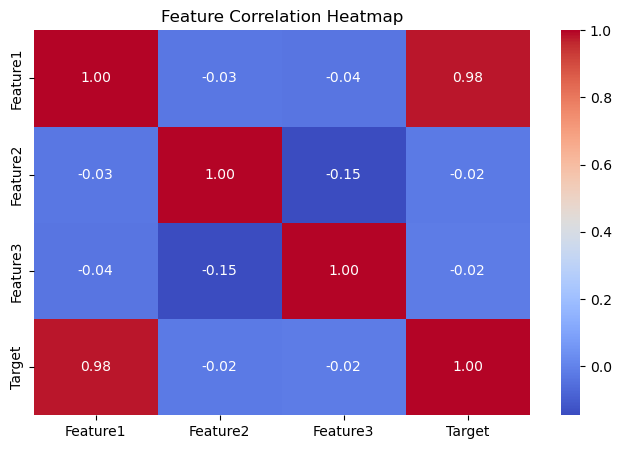

Mean Squared Error: 8.41
R-squared: 0.91


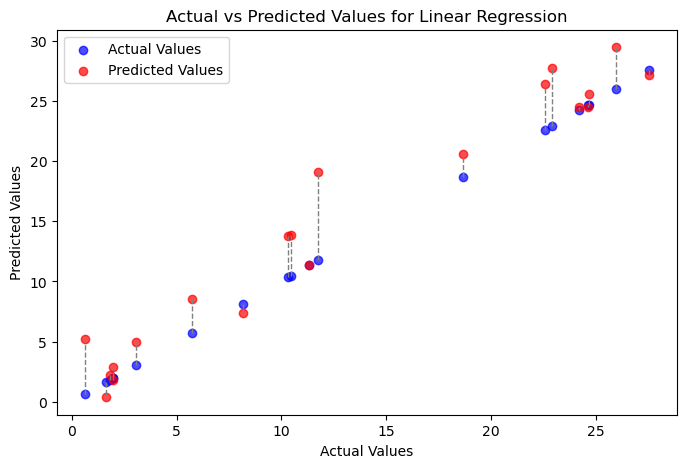

In [2]:
np.random.seed(42)
n_samples = 100

X1 = np.random.rand(n_samples) * 10 
X2 = np.random.rand(n_samples) * 10 
X3 = np.random.rand(n_samples) * 10 
Y = X1 * 3 + np.random.normal(0, 2, n_samples) 

df = pd.DataFrame({'Feature1': X1, 'Feature2': X2, 'Feature3': X3, 'Target': Y})

display(df.head())

plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

X = df[['Feature1', 'Feature2', 'Feature3']]
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_test, color='blue', label='Actual Values', alpha=0.7)
plt.scatter(y_test, y_pred, color='red', label='Predicted Values', alpha=0.7)

for actual, predicted in zip(y_test, y_pred):
    plt.plot([actual, actual], [actual, predicted], color='gray', linestyle='dashed', linewidth=1)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values for Linear Regression")
plt.legend()
plt.show()

In [64]:
url = "https://raw.githubusercontent.com/cstorm125/information_value/refs/heads/master/data/120-years-of-olympic-history-athletes-and-results/athlete_events.csv"
df_clean = pd.read_csv(url)
# df.head(5)
# df_clean = df_clean[df_clean['Sport'] == 'Basketball']
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [65]:
import pandas as pd

medal_dummies = pd.get_dummies(df_clean['Medal'])

df_processed = pd.concat([df_clean, medal_dummies], axis=1)

athlete_df = df_processed.groupby('Name').agg({
    'Age': 'mean',
    'Height': 'mean',
    'Weight': 'mean',
    'Gold': 'sum',
    'Silver': 'sum',
    'Bronze': 'sum',
    'ID': 'count'
}).rename(columns={'ID': 'Total_Events'})

athlete_df['Total_Medals'] = athlete_df['Gold'] + athlete_df['Silver'] + athlete_df['Bronze']
athlete_df = athlete_df[athlete_df['Total_Medals'] > 0]


In [66]:
athlete_df.dropna(inplace=True)
athlete_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20764 entries, A. Joshua "Josh" West to ystein Pettersen
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           20764 non-null  float64
 1   Height        20764 non-null  float64
 2   Weight        20764 non-null  float64
 3   Gold          20764 non-null  int64  
 4   Silver        20764 non-null  int64  
 5   Bronze        20764 non-null  int64  
 6   Total_Events  20764 non-null  int64  
 7   Total_Medals  20764 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 1.4+ MB


In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_cols = ['Age', 'Height', 'Weight', 'Total_Events']
X = athlete_df[X_cols].fillna(athlete_df.mean())
y = athlete_df['Total_Medals']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
y_pred_int = np.round(y_pred).astype(int)
y_pred_int = np.clip(y_pred_int, a_min=0, a_max=None)

results = pd.DataFrame({
    'Actual': y_test.values,
    'Final_cont_pred' : y_pred,
    'Final_Int_Pred': y_pred_int
})

results.info()

accuracy = results[results['Actual'] == results['Final_Int_Pred']].count()
accuracy



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4153 entries, 0 to 4152
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Actual           4153 non-null   int64  
 1   Final_cont_pred  4153 non-null   float64
 2   Final_Int_Pred   4153 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 97.5 KB


Actual             2792
Final_cont_pred    2792
Final_Int_Pred     2792
dtype: int64